# Customer Shopping Behavior Analysis - June 26, 2026 - lacaug0782

Overview
The purpose of this project is to analyze customer purchasing behavior using the Instacart Online Grocery Basket Analysis dataset. The project will explore purchasing patterns, identify distinct customer segments, and develop product recommendations based on customer behavior. Understanding these patterns can help retailers improve product recommendations, personalize marketing efforts, and increase customer engagement.

In [1]:
import numpy as np 
import pandas as pd
from datetime import datetime
import os
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from scipy.stats import kruskal
from sklearn.preprocessing import StandardScaler

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "lacaug0782"

display(Markdown("## Customer Shopping Behavior Analysis "))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## Customer Shopping Behavior Analysis 

Date: 2026-07-25

Student ID: lacaug0782

# Data Cleaning, EDA, and Preprocessing

In [2]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 1: Load the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

path = kagglehub.dataset_download("yasserh/instacart-online-grocery-basket-analysis-dataset")

print("Path to dataset files:", path)

#Customer Shopping Behavior Analysis / Step 1: Load the Data

Date: 2026-07-25

Student ID: lacaug0782

Path to dataset files: C:\Users\lacey\.cache\kagglehub\datasets\yasserh\instacart-online-grocery-basket-analysis-dataset\versions\1


In [3]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 1.2: Understand the Dataset Structure"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

aisles = pd.read_csv(f"{path}/aisles.csv")
departments = pd.read_csv(f"{path}/departments.csv")
orders = pd.read_csv(f"{path}/orders.csv")
products = pd.read_csv(f"{path}/products.csv")
order_products_prior = pd.read_csv(f"{path}/order_products__prior.csv")

print(aisles.head())
print(departments.head())
print(orders.head())
print(products.head())
print(order_products_prior.head())

#Customer Shopping Behavior Analysis / Step 1.2: Understand the Dataset Structure

Date: 2026-07-25

Student ID: lacaug0782

   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                

## Step 1: Load the Data

The Instacart dataset was imported into Python and reviewed to understand the available tables and features. Each file provides different information about customers, products, departments, aisles, and purchase history.

**Why this step is important**

Understanding how each table relates to the others is necessary before combining the data into a single dataset for analysis.

In [4]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 2: Check Data Quality"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

#Missing Values
print("#Missing Values")
print("Orders - Missing Values") 
print(orders.isnull().sum())
print("\nProducts - Missing Values") 
print(products.isnull().sum())
print("\nOrder Products Prior - Missing Values") 
print(order_products_prior.isnull().sum())

#Duplicates
print("#Duplicates")
print("Orders Duplicates:", orders.duplicated().sum())
print("Products Duplicates:", products.duplicated().sum())
print("Order Products Prior Duplicates:", order_products_prior.duplicated().sum())

#Data Summary
print("#Data Summary")
orders.info()
products.info()
aisles.info()
departments.info()
order_products_prior.info()

#Customer Shopping Behavior Analysis / Step 2: Check Data Quality

Date: 2026-07-25

Student ID: lacaug0782

#Missing Values
Orders - Missing Values
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Products - Missing Values
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Order Products Prior - Missing Values
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
#Duplicates
Orders Duplicates: 0
Products Duplicates: 0
Order Products Prior Duplicates: 0
#Data Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow   

## Step 2: Check Data Quality

Before performing any analysis, the data was reviewed for missing values, duplicate records, and data types to ensure the dataset was suitable for analysis.

### Findings

- Most datasets contained complete information.
- Missing values were found in `days_since_prior_order`.
- These missing values represent a customer's first order and are expected rather than data quality issues.
- No significant duplicate records were identified.

**How this supports the project**

Reviewing data quality increases confidence that later analysis and machine learning models will be built using reliable data.

In [5]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 3: Merge Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

#smaller sample of purchase records for analysis
order_products_sample = order_products_prior.sample(
    n=500000,
    random_state=42
)

order_details = pd.merge(order_products_sample, products, on="product_id")
order_details = pd.merge(order_details, orders, on="order_id")
order_details = pd.merge(order_details, aisles, on="aisle_id")
order_details = pd.merge(order_details, departments, on="department_id")

order_details.head()
order_details.info()

#Customer Shopping Behavior Analysis / Step 3: Merge Data

Date: 2026-07-25

Student ID: lacaug0782

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                500000 non-null  int64  
 1   product_id              500000 non-null  int64  
 2   add_to_cart_order       500000 non-null  int64  
 3   reordered               500000 non-null  int64  
 4   product_name            500000 non-null  object 
 5   aisle_id                500000 non-null  int64  
 6   department_id           500000 non-null  int64  
 7   user_id                 500000 non-null  int64  
 8   eval_set                500000 non-null  object 
 9   order_number            500000 non-null  int64  
 10  order_dow               500000 non-null  int64  
 11  order_hour_of_day       500000 non-null  int64  
 12  days_since_prior_order  467945 non-null  float64
 13  aisle                   500000 non-null  object 
 14  department          

## Step 3: Merge the Data

The individual Instacart tables were merged into a single analysis dataset containing customer information, purchase history, products, departments, and aisles.

Because the complete dataset exceeded available system memory, a random sample of purchase records was used while maintaining representative customer shopping behavior.

### Findings

- Created one analysis dataset with customer, product, and order information.
- Combined behavioral and product information into a single table.
- Prepared the dataset for exploratory analysis.

**How this supports the project**

The merged dataset contains the information needed to support all three project objectives:

- Market Basket Analysis
- Customer Segmentation
- Product Recommendation Modeling

#Customer Shopping Behavior Analysis / Step 4: Univariate Analysis

Date: 2026-07-25

Student ID: lacaug0782

## Summary Statistics

,add_to_cart_order,reordered,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,467945.000000
mean,8.363160,0.589302,17.115786,2.735148,13.434576,11.110252
std,7.145807,0.491961,17.472609,2.089889,4.249730,8.776726
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,5.000000,1.000000,10.000000,5.000000
50%,6.000000,1.000000,11.000000,3.000000,13.000000,8.000000
75%,11.000000,1.000000,24.000000,5.000000,16.000000,15.000000
max,136.000000,1.000000,99.000000,6.000000,23.000000,30.000000


,add_to_cart_order,reordered,order_number,order_dow,order_hour_of_day,days_since_prior_order
mean,8.363160,0.589302,17.115786,2.735148,13.434576,11.110252
median,6.000000,1.000000,11.000000,3.000000,13.000000,8.000000
std,7.145807,0.491961,17.472609,2.089889,4.249730,8.776726
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,136.000000,1.000000,99.000000,6.000000,23.000000,30.000000


## Histograms

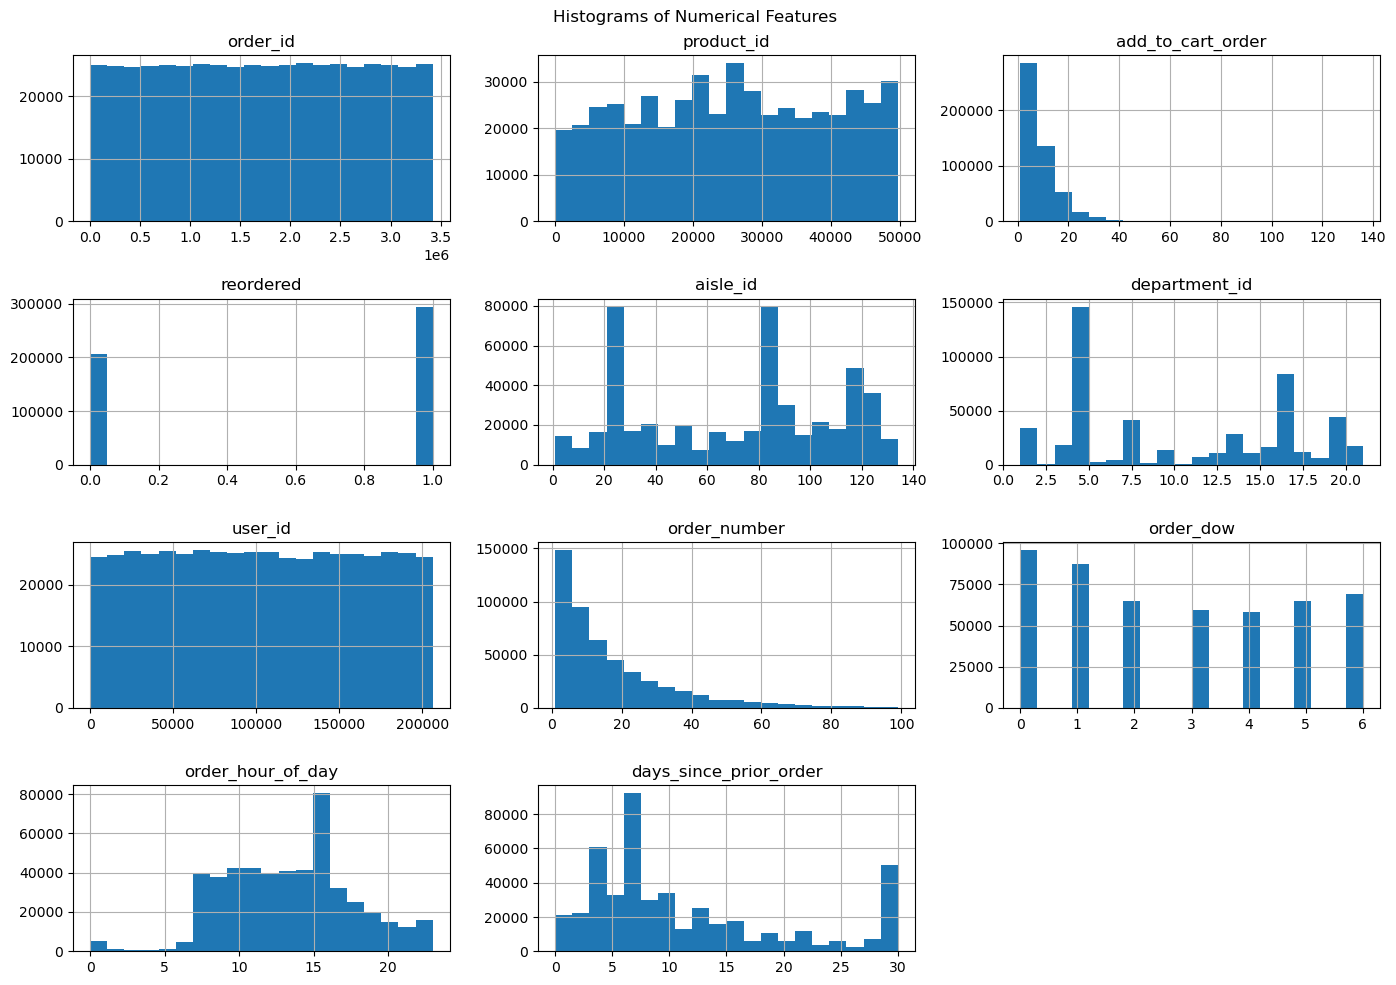

## Boxplots

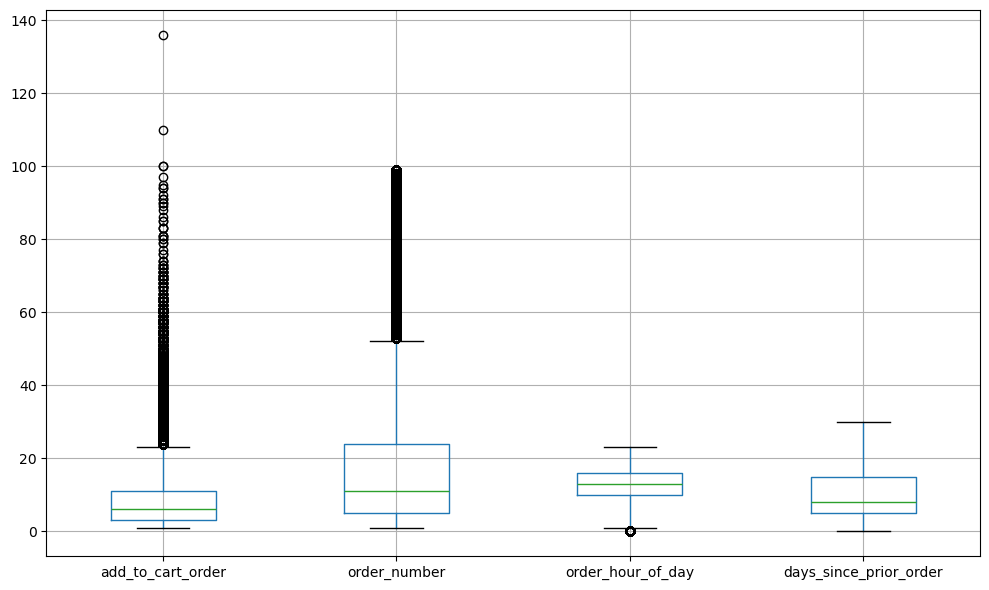

In [6]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 4: Univariate Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

display(Markdown("## Summary Statistics"))

relevant_features = [
    'add_to_cart_order',
    'reordered',
    'order_number',
    'order_dow',
    'order_hour_of_day',
    'days_since_prior_order']

display(order_details[relevant_features].describe())

display(
    order_details[relevant_features].agg([
        'mean',
        'median',
        'std',
        'min',
        'max'
    ]))

display(Markdown("## Histograms"))

numeric_columns = order_details.select_dtypes(include=["int64", "float64"]).columns

order_details[numeric_columns].hist(
    figsize=(14, 10),
    bins=20)

plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

display(Markdown("## Boxplots"))

order_details[
    [
        'add_to_cart_order',
        'order_number',
        'order_hour_of_day',
        'days_since_prior_order'
    ]
].boxplot(figsize=(10,6))

plt.tight_layout()
plt.show()


## Step 4: Univariate Analysis

Summary statistics, histograms, and boxplots were used to better understand each variable individually.

### Findings

- Most customers purchase relatively small grocery orders.
- Approximately 59% of purchased products are repeat purchases.
- Customers typically shop every week.
- Shopping activity peaks during the early afternoon.
- Some customers place significantly larger orders than others.

**How this supports the project**

These findings provide an understanding of customer shopping behavior before identifying customer segments or product relationships.

#Customer Shopping Behavior Analysis / Step 5: Bivariate Analysis

Date: 2026-07-25

Student ID: lacaug0782

## Correlation Matrix

,order_id,product_id,add_to_cart_order,reordered,aisle_id,department_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
order_id,1.000000,0.001527,0.000029,-0.001618,-0.000878,-0.000624,-0.002092,-0.001486,0.000750,0.000256,0.001307
product_id,0.001527,1.000000,0.005240,0.002155,0.001082,-0.029160,-0.000785,-0.002024,-0.002437,0.003747,-0.000742
add_to_cart_order,0.000029,0.005240,1.000000,-0.134102,0.008880,0.031708,0.000013,-0.004214,-0.009055,-0.014471,0.054302
reordered,-0.001618,0.002155,-0.134102,1.000000,0.005598,-0.040783,-0.001410,0.307135,-0.006075,-0.022084,-0.132663
aisle_id,-0.000878,0.001082,0.008880,0.005598,1.000000,0.061602,-0.001741,-0.000440,-0.002852,0.001540,0.007800
department_id,-0.000624,-0.029160,0.031708,-0.040783,0.061602,1.000000,-0.000091,0.000511,0.006099,-0.006745,0.000340
user_id,-0.002092,-0.000785,0.000013,-0.001410,-0.001741,-0.000091,1.000000,0.001247,-0.002590,-0.001025,-0.000972
order_number,-0.001486,-0.002024,-0.004214,0.307135,-0.000440,0.000511,0.001247,1.000000,0.016872,-0.039709,-0.357601
order_dow,0.000750,-0.002437,-0.009055,-0.006075,-0.002852,0.006099,-0.002590,0.016872,1.000000,0.013792,-0.031209
order_hour_of_day,0.000256,0.003747,-0.014471,-0.022084,0.001540,-0.006745,-0.001025,-0.039709,0.013792,1.000000,0.003524


## Correlation Heatmap

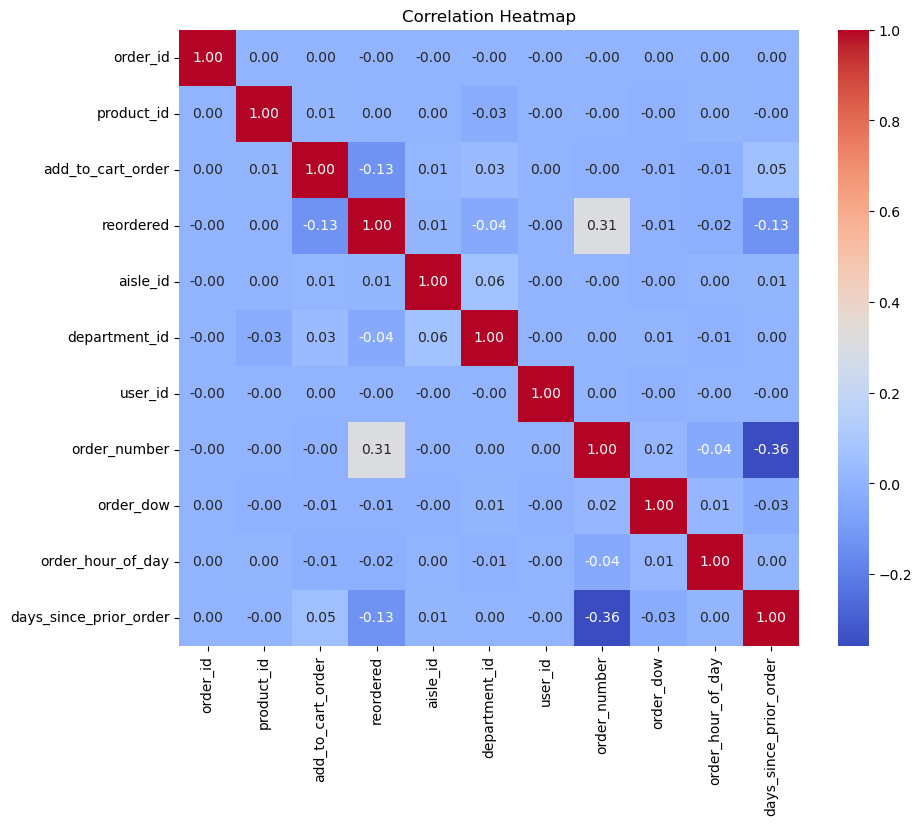

## Pair Plot for Clustering Features

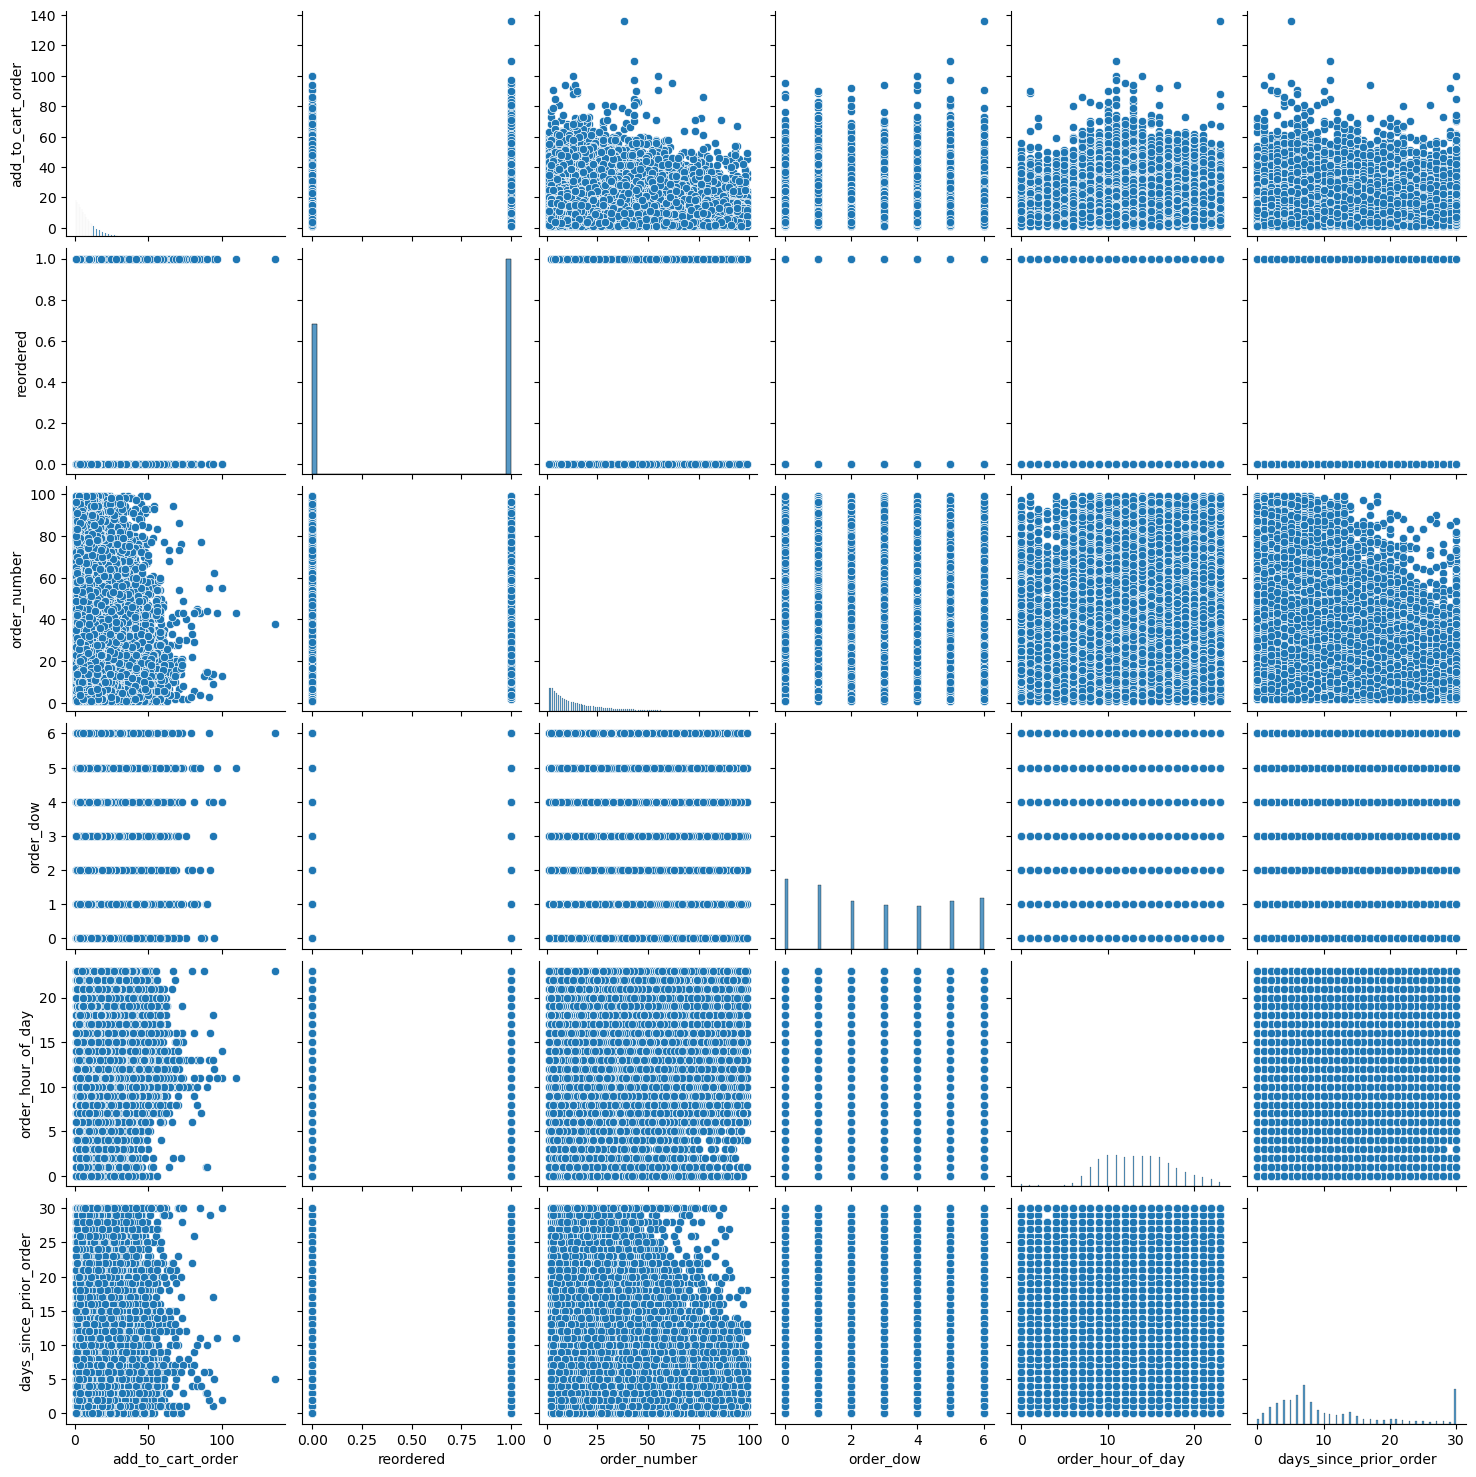

In [7]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 5: Bivariate Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

#  CORRELATION MATRIX
display(Markdown("## Correlation Matrix"))
corr_matrix = order_details.corr(numeric_only=True)
display(corr_matrix)

#  CORRELATION HEATMAP
display(Markdown("## Correlation Heatmap"))
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# PAIR PLOT FOR CLUSTERING FEATURES 
display(Markdown("## Pair Plot for Clustering Features"))
cluster_features = [
   'add_to_cart_order',
    'reordered',
    'order_number',
    'order_dow',
    'order_hour_of_day',
    'days_since_prior_order']

available_cluster_features = [
    col for col in cluster_features if col in order_details.columns
]
sns.pairplot(order_details[available_cluster_features])
plt.show()

## Step 5: Bivariate Analysis

Correlation analysis, heatmaps, and pair plots were used to explore relationships between multiple variables.

### Findings

- Most variables showed weak correlations.
- Customers with longer purchase histories are more likely to reorder products.
- Frequent customers generally shop more often.
- No obvious customer segments were visible using simple visualizations.

**How this supports the project**

The results suggest that clustering techniques will be useful for identifying customer segments and that multiple variables will likely contribute to future recommendation models.

In [8]:
display(Markdown("#Customer Shopping Behavior Analysis / Step 6: Business EDA"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

display(Markdown("### Top 20 Products"))
display(order_details.product_name.value_counts().head(20))

display(Markdown("### Top Departments"))
display(order_details.department.value_counts().head(5))

display(Markdown("### Top Aisles"))
display(order_details.aisle.value_counts().head(5))

display(Markdown("### Orders by Day of Week"))
display(order_details.order_dow.value_counts().head(10))

display(Markdown("### Orders by Hour"))
display(order_details.order_hour_of_day.value_counts().head(10))

#Customer Shopping Behavior Analysis / Step 6: Business EDA

Date: 2026-07-25

Student ID: lacaug0782

### Top 20 Products

product_name
Banana                      7290
Bag of Organic Bananas      5782
Organic Strawberries        4099
Organic Baby Spinach        3753
Organic Hass Avocado        3231
Organic Avocado             2776
Large Lemon                 2362
Strawberries                2184
Organic Raspberries         2133
Organic Whole Milk          2098
Limes                       2096
Organic Yellow Onion        1711
Organic Garlic              1702
Organic Zucchini            1672
Organic Blueberries         1576
Cucumber Kirby              1492
Organic Fuji Apple          1409
Seedless Red Grapes         1351
Organic Lemon               1350
Apple Honeycrisp Organic    1307
Name: count, dtype: int64

...

aisle
fresh fruits                  56097
fresh vegetables              52689
packaged vegetables fruits    27335
yogurt                        22328
packaged cheese               15214
Name: count, dtype: int64

### Orders by Day of Week

order_dow
0    95978
1    87497
6    69180
5    64887
2    64870
3    59530
4    58058
Name: count, dtype: int64

### Orders by Hour

order_hour_of_day
10    42486
11    42407
14    41607
15    41132
13    40990
12    40064
16    39398
9     37905
17    32096
8     26471
Name: count, dtype: int64

## Step 6: Business Exploratory Data Analysis

Business-focused analysis was performed to better understand customer purchasing behavior and shopping trends.

### Findings

- Fresh produce dominates the most frequently purchased products.
- Produce is the most popular department.
- Fresh Fruits is the most frequently purchased aisle.
- Shopping activity is highest during normal daytime hours.
- Organic products appear frequently among the most purchased items.

### Business Insights

The results suggest customers regularly purchase fresh foods and frequently reorder staple grocery items. These trends may support targeted marketing, personalized recommendations, and future customer segmentation.

**How this supports the project**

- **Market Basket Analysis:** Identifies popular products and categories before discovering products purchased together.
- **Customer Segmentation:** Reveals differences in shopping frequency, purchasing habits, and shopping times.
- **Recommendation Model:** Identifies popular products and shopping behaviors that can be used to recommend future purchases.

## Data Preparation Summary

The dataset has been cleaned, reviewed, and prepared for exploratory analysis.

### Data preparation completed

- Reviewed missing values
- Reviewed duplicate records
- Verified data types
- Merged related datasets
- Sampled the data to improve performance
- Completed exploratory and business analysis

Additional preprocessing steps such as encoding categorical variables, feature scaling, and feature engineering will be completed during the machine learning phase of the project.

# Predictive Modeling and Recommendation Model Development

## Part 1: Data Preparation

In [9]:
display(Markdown("# Customer Shopping Behavior Analysis / Step 1: Prepare Data for M.L. "))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create a working copy
model_data = order_details.copy()

# Keep only the columns needed
model_data = model_data[
    [
        "order_id",
        "user_id",
        "product_id",
        "product_name",
        "aisle",
        "department",
        "order_dow",
        "order_hour_of_day",
        "days_since_prior_order",
        "reordered"
    ]
]

# Identify first orders BEFORE replacing missing values
model_data["first_order"] = (
    model_data["days_since_prior_order"]
    .isna()
    .astype(int)
)

# Replace missing days-since-prior-order values with 0
model_data["days_since_prior_order"] = (
    model_data["days_since_prior_order"]
    .fillna(0)
)

display(model_data.head(), model_data.shape)

# Customer Shopping Behavior Analysis / Step 1: Prepare Data for M.L. 

Date: 2026-07-25

Student ID: lacaug0782

,order_id,user_id,product_id,product_name,aisle,department,order_dow,order_hour_of_day,days_since_prior_order,reordered,first_order
0,3109255,135284,34099,Crushed Red Chili Pepper,spices seasonings,pantry,0,19,8.0,0,0
1,301098,7293,41950,Organic Tomato Cluster,fresh vegetables,produce,4,15,1.0,0,0
2,1181866,111385,45066,Honeycrisp Apple,fresh fruits,produce,1,17,8.0,0,0
3,1678630,147365,8859,Natural Spring Water,water seltzer sparkling water,beverages,0,14,26.0,1,0
4,644090,99290,24781,"PODS Laundry Detergent, Ocean Mist Designed fo...",laundry,household,0,19,30.0,0,0


(500000, 11)

# Step 1: Prepare Data for Machine Learning
### Objective
Prepare the original Instacart purchase data for machine learning by selecting the required variables, handling missing values, and creating a clean working dataset for analysis.

### Key Results
- Created a working dataset containing **500,000 purchase records**.
- Selected the variables needed for customer segmentation and recommendation modeling.
- Replaced missing values in `days_since_prior_order` with 0.
- Prepared the dataset for feature engineering and customer behavior analysis.

**How this supports the project**
A clean and consistent dataset provides the foundation for creating customer behavior features, building customer segments, and developing an accurate product recommendation model.

In [10]:
display(Markdown("# Customer Shopping Behavior Analysis /Step 2: Create Customer Features"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Calculate the size of each order
order_sizes = model_data.groupby(["user_id", "order_id"]).size().reset_index(name="basket_size")

# Create customer shopping behavior features
customer_features = model_data.groupby("user_id").agg(
    total_orders=("order_id", "nunique"),
    total_products=("product_id", "count"),
    average_days_between_orders=(
        "days_since_prior_order",
        "mean")).reset_index()

# Calculate average basket size
average_basket_size = order_sizes.groupby("user_id").agg(
    average_basket_size=("basket_size", "mean")).reset_index()

# Add average basket size
customer_features = customer_features.merge(
    average_basket_size,
    on="user_id",
    how="left")

# Identify products containing the word organic
model_data["organic_product"] = (
    model_data["product_name"]
    .str.contains("organic", case=False, na=False)
    .astype(int))

# Calculate each customer's organic product percentage
organic_percentage = model_data.groupby("user_id").agg(
    organic_percentage=("organic_product", "mean")).reset_index()

# Add organic product percentage
customer_features = customer_features.merge(
    organic_percentage,
    on="user_id",
    how="left")

# Calculate department purchase percentages
department_percentages = pd.crosstab(
    model_data["user_id"],
    model_data["department"],
    normalize="index").reset_index()

# Select the departments used for segmentation
selected_departments = [
    "produce",
    "dairy eggs",
    "snacks",
    "beverages",
    "frozen",
    "pantry",
    "household",
    "meat seafood"]

# Add missing department columns if needed
for department in selected_departments:
    if department not in department_percentages.columns:
        department_percentages[department] = 0

# Keep the selected department percentages
department_percentages = department_percentages[
    ["user_id"] + selected_departments]

# Rename department columns
department_percentages = department_percentages.rename(
    columns={
        "produce": "produce_percentage",
        "dairy eggs": "dairy_eggs_percentage",
        "snacks": "snacks_percentage",
        "beverages": "beverages_percentage",
        "frozen": "frozen_percentage",
        "pantry": "pantry_percentage",
        "household": "household_percentage",
        "meat seafood": "meat_seafood_percentage"})

# Add department preferences
customer_features = customer_features.merge(
    department_percentages,
    on="user_id",
    how="left")

# Calculate the average reorder rate
reorder_rate = model_data.groupby("user_id").agg(
    reorder_rate=("reordered", "mean")).reset_index()

# Add the reorder rate
customer_features = customer_features.merge(
    reorder_rate,
    on="user_id",
    how="left")

# Display the completed customer feature dataset
display(customer_features.head())
display(customer_features.shape)

# Customer Shopping Behavior Analysis /Step 2: Create Customer Features

Date: 2026-07-25

Student ID: lacaug0782

,user_id,total_orders,total_products,average_days_between_orders,average_basket_size,organic_percentage,produce_percentage,dairy_eggs_percentage,snacks_percentage,beverages_percentage,frozen_percentage,pantry_percentage,household_percentage,meat_seafood_percentage,reorder_rate
0,2,2,2,17.00,1.0,0.00,0.0,1.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0
1,6,1,1,0.00,1.0,1.00,1.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
2,7,4,4,11.75,1.0,0.25,0.0,0.25,0.25,0.25,0.0,0.0,0.0,0.0,0.5
3,9,1,2,30.00,2.0,0.00,0.0,0.00,0.50,0.00,0.0,0.5,0.0,0.0,1.0
4,11,1,1,7.00,1.0,0.00,0.0,1.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0


(139810, 15)

# Step 2: Create Customer Features
### Objective
Create customer-level features that summarize purchasing behavior and product preferences for each shopper.

### Key Results
- Aggregated purchase history into a single record for each customer.
- Created behavioral features including purchase frequency, basket size, reorder rate, and department purchase percentages.
- Added product preference measures such as organic purchasing behavior.
- Built a customer-level dataset for segmentation.

**How this supports the project**
These features describe how customers shop rather than what they purchased in a single order, providing meaningful inputs for customer segmentation and personalized recommendations.

In [11]:
display(Markdown("# Customer Shopping Behavior Analysis /Step 3 : Prepare Segmentation Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.preprocessing import StandardScaler

# Select the features used for customer segmentation
segmentation_columns = [
    "total_orders",
    "average_basket_size",
    "average_days_between_orders",
    "reorder_rate",
    "organic_percentage",
    "produce_percentage",
    "dairy_eggs_percentage",
    "snacks_percentage",
    "beverages_percentage",
    "frozen_percentage",
    "pantry_percentage",
    "household_percentage",
    "meat_seafood_percentage"]

# Create a dataset containing only the segmentation features
segmentation_data = customer_features[segmentation_columns].copy()

# Fill missing values
segmentation_data = segmentation_data.fillna(0)

# Scale the segmentation features
segmentation_scaler = StandardScaler()

scaled_segmentation_data = segmentation_scaler.fit_transform(segmentation_data)

# Display the segmentation features
display(segmentation_data.head())

# Customer Shopping Behavior Analysis /Step 3 : Prepare Segmentation Data

Date: 2026-07-25

Student ID: lacaug0782

,total_orders,average_basket_size,average_days_between_orders,reorder_rate,organic_percentage,produce_percentage,dairy_eggs_percentage,snacks_percentage,beverages_percentage,frozen_percentage,pantry_percentage,household_percentage,meat_seafood_percentage
0,2,1.0,17.00,1.0,0.00,0.0,1.00,0.00,0.00,0.0,0.0,0.0,0.0
1,1,1.0,0.00,0.0,1.00,1.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0
2,4,1.0,11.75,0.5,0.25,0.0,0.25,0.25,0.25,0.0,0.0,0.0,0.0
3,1,2.0,30.00,1.0,0.00,0.0,0.00,0.50,0.00,0.0,0.5,0.0,0.0
4,1,1.0,7.00,1.0,0.00,0.0,1.00,0.00,0.00,0.0,0.0,0.0,0.0


# Step 3: Prepare Segmentation Data
### Objective
Select the customer behavior features used for clustering and standardize them before applying K-Means.

### Key Results
- Selected behavioral features that represent customer purchasing habits.
- Standardized all features using StandardScaler.
- Ensured every feature contributed equally during clustering.
- Created the final dataset used for customer segmentation.

**How this supports the project**
Standardizing the behavioral features improves clustering quality and helps identify customer groups based on overall shopping behavior rather than differences in feature scale.

## Part 2: Customer Segmentation

# Customer Shopping Behavior Analysis/Step 4: Determine the # of Segments

Date: 2026-07-25

Student ID: lacaug0782

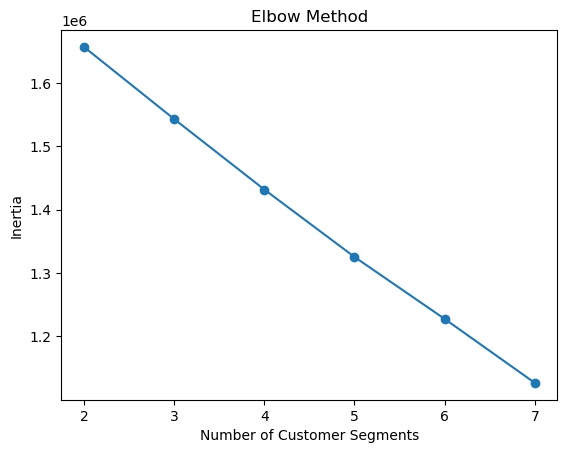

,number_of_clusters,silhouette_score
0,2,0.096568
1,3,0.099385
2,4,0.108417
3,5,0.127338
4,6,0.155160
5,7,0.160987


In [12]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 4: Determine the # of Segments"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Test different numbers of customer segments
cluster_range = range(2, 8)

# Store the evaluation results
inertia_values = []
silhouette_results = []

# Create a sample for silhouette scoring
rng = np.random.default_rng(42)
sample_indices = rng.choice(
    len(scaled_segmentation_data),
    size=10000,
    replace=False)
silhouette_sample = scaled_segmentation_data[sample_indices]

# Train a K-Means model for each number of clusters
for k in cluster_range:
    test_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = test_model.fit_predict(scaled_segmentation_data)

    # Save the inertia value
    inertia_values.append(test_model.inertia_)

     #Score the sample using the trained model
    sample_labels = test_model.predict(silhouette_sample)
    silhouette_results.append(silhouette_score(silhouette_sample, sample_labels))

# Plot the elbow method
plt.plot(list(cluster_range), inertia_values, marker="o")
plt.xlabel("Number of Customer Segments")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Display the silhouette scores
display(pd.DataFrame({"number_of_clusters": list(cluster_range),"silhouette_score": silhouette_results}))

# Step 4: Determine the Number of Customer Segments
### Objective
Evaluate multiple clustering solutions to determine an appropriate number of customer segments.

### Key Results
- Compared clustering solutions ranging from **2 to 7 customer segments**.
- Evaluated each solution using both the Elbow Method and Silhouette Score.
- Selected **6 customer segments** because they provided the best balance between cluster quality and meaningful customer differentiation.
- Established the final clustering approach used throughout the remainder of the project.

**How this supports the project**
Selecting an appropriate number of customer segments creates meaningful customer groups that improve customer profiling and provide additional information for the recommendation model.

In [13]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 5: Build Customer Segments"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))


# Create the K-Means clustering model
kmeans_model = KMeans(
    n_clusters=6,  
    random_state=42,
    n_init=10)

# Assign each customer to a segment
customer_features["customer_segment"] = kmeans_model.fit_predict(scaled_segmentation_data)

# Display the customer segments
display(customer_features.head())
display(customer_features["customer_segment"].value_counts().sort_index())

# Customer Shopping Behavior Analysis/Step 5: Build Customer Segments

Date: 2026-07-25

Student ID: lacaug0782

,user_id,total_orders,total_products,average_days_between_orders,average_basket_size,organic_percentage,produce_percentage,dairy_eggs_percentage,snacks_percentage,beverages_percentage,frozen_percentage,pantry_percentage,household_percentage,meat_seafood_percentage,reorder_rate,customer_segment
0,2,2,2,17.00,1.0,0.00,0.0,1.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,1
1,6,1,1,0.00,1.0,1.00,1.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,5
2,7,4,4,11.75,1.0,0.25,0.0,0.25,0.25,0.25,0.0,0.0,0.0,0.0,0.5,0
3,9,1,2,30.00,2.0,0.00,0.0,0.00,0.50,0.00,0.0,0.5,0.0,0.0,1.0,0
4,11,1,1,7.00,1.0,0.00,0.0,1.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,1


customer_segment
0    42010
1    17914
2    28697
3    11681
4     3357
5    36151
Name: count, dtype: int64

# Step 5: Build Customer Segments
### Objective
Train the K-Means clustering model and assign each customer to a behavioral segment.

### Key Results
- Successfully assigned every customer to one of **6 customer segments**.
- Added a `customer_segment` value to each customer record.
- Created the customer segment assignments used throughout the recommendation model.
- Completed the customer segmentation process.

**How this supports the project**
Customer segments capture differences in shopping behavior and allow the recommendation model to incorporate customer purchasing patterns in addition to product relationships.

In [14]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 6: Analyze Customer Segments"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create an average profile for each customer segment
segment_profiles = (
    customer_features
    .groupby("customer_segment")[segmentation_columns]
    .mean()
    .round(6))

# Create a display copy
segment_profiles_display = segment_profiles.copy()

# Convert percentage features to percentages
percentage_columns = [
    "reorder_rate",
    "organic_percentage",
    "produce_percentage",
    "dairy_eggs_percentage",
    "snacks_percentage",
    "beverages_percentage",
    "frozen_percentage",
    "pantry_percentage",
    "household_percentage",
    "meat_seafood_percentage"]

segment_profiles_display[percentage_columns] = (segment_profiles_display[percentage_columns] * 100).round(1)

# Create a customer and segment lookup table
customer_segment_lookup = customer_features[
    ["user_id", "customer_segment"]]

# Add customer segments to purchase history
segmented_purchase_data = model_data.merge(
    customer_segment_lookup,
    on="user_id",
    how="left")

# Find the top five departments for each segment
top_departments_by_segment = (
    segmented_purchase_data
    .groupby(["customer_segment", "department"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values(
        ["customer_segment", "purchase_count"],
        ascending=[True, False]    )
    .groupby("customer_segment")
    .head(5))

# Find the top ten products for each segment
top_products_by_segment = (
    segmented_purchase_data
    .groupby(["customer_segment", "product_name"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values(
        ["customer_segment", "purchase_count"],
        ascending=[True, False]    )
    .groupby("customer_segment")
    .head(10))

# Display the customer segment profiles
print("Customer Segment Profiles")
display(segment_profiles_display)


# Display the top departments
print("Top Departments by Customer Segment")
display(top_departments_by_segment)

# Display the top products
print("Top Products by Customer Segment")
display(top_products_by_segment)

# Customer Shopping Behavior Analysis/Step 6: Analyze Customer Segments

Date: 2026-07-25

Student ID: lacaug0782

Customer Segment Profiles


,total_orders,average_basket_size,average_days_between_orders,reorder_rate,organic_percentage,produce_percentage,dairy_eggs_percentage,snacks_percentage,beverages_percentage,frozen_percentage,pantry_percentage,household_percentage,meat_seafood_percentage
customer_segment,,,,,,,,,,,,,
0,2.066794,1.112627,13.561396,36.4,12.2,6.8,5.2,20.4,2.5,17.1,13.7,1.1,0.4
1,2.004242,1.074822,13.226727,49.5,28.6,9.2,74.9,1.9,1.1,1.6,1.2,0.4,0.2
2,7.674774,1.133545,8.728495,67.4,32.2,27.2,16.4,7.7,7.2,5.6,4.9,1.8,9.8
3,1.972434,1.067288,13.140841,51.7,12.2,6.5,5.2,3.4,72.5,2.1,1.6,0.7,0.4
4,1.725946,1.068896,13.992285,30.6,4.7,4.8,4.0,2.5,3.7,1.6,2.2,74.2,0.7
5,2.122791,1.083263,13.180296,46.9,52.6,73.7,4.0,1.8,1.5,1.7,1.8,0.3,0.2


Top Departments by Customer Segment


,customer_segment,department,purchase_count
20,0,snacks,18179
10,0,frozen,15359
16,0,pantry,11917
19,0,produce,9836
7,0,dairy eggs,7658
28,1,dairy eggs,25206
40,1,produce,4627
41,1,snacks,1052
23,1,bakery,987
31,1,frozen,883


Top Products by Customer Segment


,customer_segment,product_name,purchase_count
1308,0,Banana,739
1800,0,Blueberries,419
5450,0,Extra Virgin Olive Oil,283
179,0,100% Whole Wheat Bread,282
12761,0,Original Hummus,255
16640,0,Strawberries,232
8514,0,Large Lemon,230
1208,0,Bag of Organic Bananas,195
8889,0,Limes,191
11029,0,Organic Broccoli Florets,164


# Step 6: Analyze Customer Segments
### Objective
Analyze each customer segment to identify purchasing behaviors, preferred departments, and commonly purchased products.

### Key Results
- Developed behavioral profiles for all six customer segments.
- Identified distinct shopping patterns across organic, dairy, beverage, household, pantry, and mixed grocery shoppers.
- Determined the most frequently purchased departments and products for each segment.
- Created meaningful customer personas based on purchasing behavior.

**How this supports the project**
Understanding the characteristics of each customer segment provides business insight into shopping behavior and supports more personalized product recommendations.

## Part 3: Recommendation Model Development

In [15]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 7: Create Positive Product Pairs"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from itertools import permutations

# Create positive product pairs
positive_pairs = []

# Find products purchased together in each order
for order_id, group in model_data.groupby("order_id"):

    products = group["product_id"].drop_duplicates().tolist()

    # Create all possible product pairs
    for anchor, candidate in permutations(products, 2):

        positive_pairs.append({
            "order_id": order_id,
            "anchor_product": anchor,
            "candidate_product": candidate,
            "purchased_together": 1})

# Convert the results to a DataFrame
positive_pair_data = pd.DataFrame(positive_pairs)

# Display the positive product pairs
display(positive_pair_data.head())
display(positive_pair_data.shape)

# Customer Shopping Behavior Analysis/Step 7: Create Positive Product Pairs

Date: 2026-07-25

Student ID: lacaug0782

,order_id,anchor_product,candidate_product,purchased_together
0,77,31040,23233,1
1,77,23233,31040,1
2,147,21938,31553,1
3,147,31553,21938,1
4,223,47842,33852,1


(113628, 4)

# Step 7: Create Positive Product Pairs
### Objective
Generate examples of products that were purchased together within the same customer order.

### Key Results
- Created **113,628 positive product pairs**.
- Assigned a target value of `1` to purchased-together product pairs.
- Captured historical purchasing relationships between products.
- Prepared positive training examples for supervised learning.

**How this supports the project**
Positive product pairs provide the recommendation model with examples of products customers actually purchased together.

In [16]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 8: Create Negative Product Pairs"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

import numpy as np

# Get a list of all unique products
all_products = model_data["product_id"].drop_duplicates().to_numpy()

# Store the products purchased in each order
products_by_order = (model_data.groupby("order_id")["product_id"]
    .apply(set)
    .to_dict())

# Initialize the random number generator
rng = np.random.default_rng(42)

# Create negative product pairs
negative_pairs = []

# Generate one negative pair for each positive pair
for row in positive_pair_data.itertuples(index=False):
    products_in_order = products_by_order[row.order_id]

    # Select a product that was not purchased in the order
    candidate = rng.choice(all_products)

    while candidate in products_in_order:
        candidate = rng.choice(all_products)

    negative_pairs.append({
        "order_id": row.order_id,
        "anchor_product": row.anchor_product,
        "candidate_product": int(candidate),
        "purchased_together": 0})

# Convert the results to a DataFrame
negative_pair_data = pd.DataFrame(negative_pairs)

# Display the negative product pairs
display(negative_pair_data.head())
display(negative_pair_data.shape)

# Customer Shopping Behavior Analysis/Step 8: Create Negative Product Pairs

Date: 2026-07-25

Student ID: lacaug0782

,order_id,anchor_product,candidate_product,purchased_together
0,77,31040,31575,0
1,77,23233,20029,0
2,147,21938,14451,0
3,147,31553,33433,0
4,223,47842,19885,0


(113628, 4)

# Step 8: Create Negative Product Pairs
### Objective
Generate examples of products that were not purchased together.

### Key Results
- Created **113,628 negative product pairs**.
- Balanced the dataset with an equal number of positive and negative examples.
- Assigned a target value of `0` to non-purchased product pairs.
- Completed the labeled training dataset.

**How this supports the project**
Including negative examples allows the recommendation model to distinguish between likely and unlikely product pairings.

In [17]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 9: Combine Product-Pair Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Combine the positive and negative product pairs
pair_data = pd.concat(
    [positive_pair_data, negative_pair_data],
    ignore_index=True)

# Shuffle the dataset
pair_data = pair_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the combined dataset 
display(pair_data.head())

# Display the target variable counts
display(pair_data["purchased_together"].value_counts())

# Customer Shopping Behavior Analysis/Step 9: Combine Product-Pair Data

Date: 2026-07-25

Student ID: lacaug0782

,order_id,anchor_product,candidate_product,purchased_together
0,2329807,22957,48871,1
1,2123894,11941,2437,0
2,2670735,790,39539,1
3,519655,31102,30352,1
4,467021,29650,15647,0


purchased_together
1    113628
0    113628
Name: count, dtype: int64

# Step 9: Combine Product-Pair Data
### Objective
Combine positive and negative product pairs into a single modeling dataset.

### Key Results
- Combined positive and negative examples into one dataset.
- Created **227,256 labeled product pairs**.
- Balanced both target classes equally.
- Randomly shuffled the records before modeling.

**How this supports the project**
A balanced supervised learning dataset improves model training and reduces bias toward either class.

In [18]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 10: Add Product Information"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create a product information lookup table
product_info = model_data[[
    "product_id", "product_name", "aisle", "department"
]].drop_duplicates(subset="product_id")

# Rename the anchor product information
anchor_info = product_info.rename(columns={
    "product_id": "anchor_product",
    "product_name": "anchor_product_name",
    "aisle": "anchor_aisle",
    "department": "anchor_department"})

# Rename the candidate product information
candidate_info = product_info.rename(columns={
    "product_id": "candidate_product",
    "product_name": "candidate_product_name",
    "aisle": "candidate_aisle",
    "department": "candidate_department"})

# Add the anchor product information
pair_data = pair_data.merge(anchor_info, on="anchor_product", how="left")

# Add the candidate product information
pair_data = pair_data.merge(candidate_info, on="candidate_product", how="left")

# Display the updated dataset 
display(pair_data.head()) 
display(pair_data.shape)

# Customer Shopping Behavior Analysis/Step 10: Add Product Information

Date: 2026-07-25

Student ID: lacaug0782

,order_id,anchor_product,candidate_product,purchased_together,anchor_product_name,anchor_aisle,anchor_department,candidate_product_name,candidate_aisle,candidate_department
0,2329807,22957,48871,1,Red Balsamic Vinegar,oils vinegars,pantry,Natural Tomato Paste,canned jarred vegetables,canned goods
1,2123894,11941,2437,0,"Tortillas, Corn, Organic",tortillas flat bread,bakery,Healing Ointment Tube,body lotions soap,personal care
2,2670735,790,39539,1,Garbanzo Beans,canned meals beans,canned goods,Milk Chocolate with Whole Hazelnuts,candy chocolate,snacks
3,519655,31102,30352,1,Sugar Free Energy Drink,energy sports drinks,beverages,Goldfish Original Baked Snack Crackers,crackers,snacks
4,467021,29650,15647,0,Pork Chorizo,meat counter,meat seafood,Honey Wheat Rolls,buns rolls,bakery


(227256, 10)

# Step 10: Add Product Information
### Objective
Add descriptive product information to each product pair.

### Key Results
- Added product names, aisles, and departments for both products.
- Preserved every product pair during the merge.
- Enriched the dataset with additional product characteristics.
- Prepared product attributes for model training.

**How this supports the project**
Product attributes help the models learn relationships between similar products beyond product identifiers alone.

In [19]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 11: Add Order & Customer Information"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create an order information lookup table
order_info = model_data[[
    "order_id", "user_id", "order_dow",
    "order_hour_of_day", "days_since_prior_order",
    "first_order"]].drop_duplicates(subset="order_id")

# Add the order information
pair_data = pair_data.merge(
    order_info, on="order_id", how="left")

# Display the updated dataset 
display(pair_data.head()) 
display(pair_data.shape)

# Customer Shopping Behavior Analysis/Step 11: Add Order & Customer Information

Date: 2026-07-25

Student ID: lacaug0782

,order_id,anchor_product,candidate_product,purchased_together,anchor_product_name,anchor_aisle,anchor_department,candidate_product_name,candidate_aisle,candidate_department,user_id,order_dow,order_hour_of_day,days_since_prior_order,first_order
0,2329807,22957,48871,1,Red Balsamic Vinegar,oils vinegars,pantry,Natural Tomato Paste,canned jarred vegetables,canned goods,103142,6,8,5.0,0
1,2123894,11941,2437,0,"Tortillas, Corn, Organic",tortillas flat bread,bakery,Healing Ointment Tube,body lotions soap,personal care,134862,0,12,7.0,0
2,2670735,790,39539,1,Garbanzo Beans,canned meals beans,canned goods,Milk Chocolate with Whole Hazelnuts,candy chocolate,snacks,191882,1,10,16.0,0
3,519655,31102,30352,1,Sugar Free Energy Drink,energy sports drinks,beverages,Goldfish Original Baked Snack Crackers,crackers,snacks,114963,1,10,8.0,0
4,467021,29650,15647,0,Pork Chorizo,meat counter,meat seafood,Honey Wheat Rolls,buns rolls,bakery,170551,0,15,21.0,0


(227256, 15)

# Step 11: Add Order & Customer Information
### Objective
Merge customer and order information into the product-pair dataset.

### Key Results
- Added customer identifiers and order information to each product pair.
- Included purchase timing through `days_since_prior_order`.
- Preserved all product-pair records.
- Completed the recommendation modeling dataset.

**How this supports the project**
Adding customer purchase history provides additional shopping context that supports more accurate recommendation predictions.

In [20]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 12: Add Customer Segment"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Add the customer segment information
pair_data = pair_data.merge(
    customer_segment_lookup,
    on="user_id",
    how="left")
# Display the updated dataset
display(pair_data.head())

# Display the customer segment counts
display(pair_data["customer_segment"].value_counts())

# Customer Shopping Behavior Analysis/Step 12: Add Customer Segment

Date: 2026-07-25

Student ID: lacaug0782

,order_id,anchor_product,candidate_product,purchased_together,anchor_product_name,anchor_aisle,anchor_department,candidate_product_name,candidate_aisle,candidate_department,user_id,order_dow,order_hour_of_day,days_since_prior_order,first_order,customer_segment
0,2329807,22957,48871,1,Red Balsamic Vinegar,oils vinegars,pantry,Natural Tomato Paste,canned jarred vegetables,canned goods,103142,6,8,5.0,0,2
1,2123894,11941,2437,0,"Tortillas, Corn, Organic",tortillas flat bread,bakery,Healing Ointment Tube,body lotions soap,personal care,134862,0,12,7.0,0,2
2,2670735,790,39539,1,Garbanzo Beans,canned meals beans,canned goods,Milk Chocolate with Whole Hazelnuts,candy chocolate,snacks,191882,1,10,16.0,0,0
3,519655,31102,30352,1,Sugar Free Energy Drink,energy sports drinks,beverages,Goldfish Original Baked Snack Crackers,crackers,snacks,114963,1,10,8.0,0,2
4,467021,29650,15647,0,Pork Chorizo,meat counter,meat seafood,Honey Wheat Rolls,buns rolls,bakery,170551,0,15,21.0,0,2


customer_segment
2    133448
0     44784
5     30308
1     11132
3      6128
4      1456
Name: count, dtype: int64

# Step 12: Add Customer Segment
### Objective
Merge customer segment assignments into the recommendation dataset.

### Key Results
- Successfully linked customer segments to every product pair.
- Added customer behavior information as a predictive feature.
- Preserved all recommendation records after merging.
- Completed the final modeling dataset.

**How this supports the project**
Customer segments allow the recommendation model to account for differences in shopping behavior when predicting product relationships.

In [21]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 13: Select Features & Target"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Select the numeric features
numeric_features = ["days_since_prior_order"]

# Select the categorical features
categorical_features = [
    "anchor_product", "candidate_product",
    "anchor_aisle", "anchor_department",
    "candidate_aisle", "candidate_department",
    "customer_segment"]

# Create the feature dataset
X = pair_data[numeric_features + categorical_features]
# Create the target variable
y = pair_data["purchased_together"]

# Display the feature dataset 
display(X.head()) 
display(X.shape) 
# Display the target variable 
display(y.head()) 
display(y.value_counts())


# Customer Shopping Behavior Analysis/Step 13: Select Features & Target

Date: 2026-07-25

Student ID: lacaug0782

,days_since_prior_order,anchor_product,candidate_product,anchor_aisle,anchor_department,candidate_aisle,candidate_department,customer_segment
0,5.0,22957,48871,oils vinegars,pantry,canned jarred vegetables,canned goods,2
1,7.0,11941,2437,tortillas flat bread,bakery,body lotions soap,personal care,2
2,16.0,790,39539,canned meals beans,canned goods,candy chocolate,snacks,0
3,8.0,31102,30352,energy sports drinks,beverages,crackers,snacks,2
4,21.0,29650,15647,meat counter,meat seafood,buns rolls,bakery,2


(227256, 8)

0    1
1    0
2    1
3    1
4    0
Name: purchased_together, dtype: int64

purchased_together
1    113628
0    113628
Name: count, dtype: int64

# Step 13: Select Features & Target
### Objective
Define the predictive features and target variable used for machine learning.

### Key Results
- Selected **8 predictive features** for model training.
- Combined behavioral, product, and customer segment information.
- Used `purchased_together` as the prediction target.
- Maintained a balanced target variable.

**How this supports the project**
Selecting relevant features focuses the models on the information most useful for predicting product recommendations.

In [22]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 14: Split & Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Split the data into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
# Preprocess the numeric and categorical features
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"),
     categorical_features)])
# Transform the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Display the dataset sizes 
print("Training Features:", X_train.shape) 
print("Testing Features:", X_test.shape) 
print("Training Target:", y_train.shape) 
print("Testing Target:", y_test.shape)

# Customer Shopping Behavior Analysis/Step 14: Split & Preprocess the Data

Date: 2026-07-25

Student ID: lacaug0782

Training Features: (181804, 8)
Testing Features: (45452, 8)
Training Target: (181804,)
Testing Target: (45452,)


# Step 14: Split & Preprocess the Data
### Objective
Split the dataset into training and testing sets, then preprocess the selected features by scaling numeric values and encoding categorical variables for machine learning.

### Key Results
- Split the dataset into **80% training** and **20% testing** sets using stratified sampling.
- Standardized the numeric feature using StandardScaler.
- Converted categorical features into a machine-readable format using One-Hot Encoding.
- Applied the same preprocessing pipeline to both machine learning models.

**How this supports the project**
Splitting and preprocessing the data prepares the dataset for model training while preventing data leakage and ensuring both models are evaluated using the same transformed features.

In [23]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 15: Build Baseline Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

# Train the model
baseline_model.fit(X_train_processed, y_train)

# Generate predictions
baseline_predictions = baseline_model.predict(X_test_processed)

# Generate prediction probabilities
baseline_probabilities = baseline_model.predict_proba(
    X_test_processed)[:, 1]

# Customer Shopping Behavior Analysis/Step 15: Build Baseline Model

Date: 2026-07-25

Student ID: lacaug0782

# Step 15: Build Baseline Model
### Objective
Train a Logistic Regression model to establish a baseline for predicting whether two products are likely to be purchased together.

### Key Results
- Trained a Logistic Regression model using the processed training dataset.
- Learned relationships between customer behavior, product information, and purchasing patterns.
- Generated predictions and recommendation probabilities for the testing dataset.
- Established a baseline model for comparison with the Neural Network.

**How this supports the project**
The Logistic Regression model provides a performance benchmark that can be compared against a more complex Neural Network to determine which approach produces the best recommendations.

In [24]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 16: Evaluate Baseline Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix)

# Calculate the model performance metrics
baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_predictions),
    "precision": precision_score(y_test, baseline_predictions),
    "recall": recall_score(y_test, baseline_predictions),
    "f1_score": f1_score(y_test, baseline_predictions),
    "roc_auc": roc_auc_score(y_test, baseline_probabilities)}

# Display the model performance
display(baseline_metrics)

# Display the classification report
print(classification_report(y_test, baseline_predictions))

# Display the confusion matrix
display(confusion_matrix(y_test, baseline_predictions))

# Customer Shopping Behavior Analysis/Step 16: Evaluate Baseline Model

Date: 2026-07-25

Student ID: lacaug0782

{'accuracy': 0.7991727536742057,
 'precision': 0.826216294021687,
 'recall': 0.7577224324562175,
 'f1_score': 0.7904884318766067,
 'roc_auc': 0.8678086156755078}

              precision    recall  f1-score   support

           0       0.78      0.84      0.81     22726
           1       0.83      0.76      0.79     22726

    accuracy                           0.80     45452
   macro avg       0.80      0.80      0.80     45452
weighted avg       0.80      0.80      0.80     45452



array([[19104,  3622],
       [ 5506, 17220]])

# Step 16: Evaluate Baseline Model
### Objective
Evaluate the performance of the Logistic Regression model using multiple classification metrics.

### Key Results
- Achieved an **accuracy of 79.9%** on the testing dataset.
- Produced a **precision of 82.6%**, **recall of 75.8%**, and an **F1-score of 79.0%**.
- Achieved a **ROC-AUC of 0.868**, indicating strong overall classification performance.
- Correctly classified most purchased-together and non-purchased product pairs while maintaining a balanced performance across both classes.

**How this supports the project**
Evaluating the baseline model establishes a measurable benchmark for determining whether a more advanced Neural Network improves recommendation performance.

In [25]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 17: Build & TrainNeural Network"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from tensorflow import keras
from tensorflow.keras import layers

# Stop training when validation loss stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True)

# Create the Neural Network model
neural_network = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid")])

# Configure the model
neural_network.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

# Train the model
history = neural_network.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1)

# Customer Shopping Behavior Analysis/Step 17: Build & TrainNeural Network

Date: 2026-07-25

Student ID: lacaug0782

Epoch 1/20
569/569 ━━━━━━━━━━━━━━━━━━━━ 84s 142ms/step - accuracy: 0.7456 - loss: 0.5088 - val_accuracy: 0.7930 - val_loss: 0.4537
Epoch 2/20
569/569 ━━━━━━━━━━━━━━━━━━━━ 84s 148ms/step - accuracy: 0.8398 - loss: 0.3693 - val_accuracy: 0.7867 - val_loss: 0.4717
Epoch 3/20
569/569 ━━━━━━━━━━━━━━━━━━━━ 81s 142ms/step - accuracy: 0.8822 - loss: 0.2798 - val_accuracy: 0.7816 - val_loss: 0.5299


# Step 17: Build & Train Neural Network
### Objective
Train a Neural Network using the same processed dataset to compare its performance with the baseline Logistic Regression model.

### Key Results
- Built a Neural Network with two hidden layers and dropout regularization.
- Trained the model using the same processed training dataset as the baseline model.
- Applied early stopping to reduce overfitting during training.
- Generated a second recommendation model for performance comparison.

**How this supports the project**
Training a Neural Network allows the project to evaluate whether a more complex machine learning model provides better recommendation performance than Logistic Regression.

In [26]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 18: Evaluate Neural Network"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Generate prediction probabilities
nn_probabilities = neural_network.predict(
    X_test_processed).ravel()
# Convert probabilities into class predictions
nn_predictions = (nn_probabilities >= 0.50).astype(int)
# Calculate the neural network performance metrics
nn_metrics = {
    "accuracy": accuracy_score(y_test, nn_predictions),
    "precision": precision_score(y_test, nn_predictions),
    "recall": recall_score(y_test, nn_predictions),
    "f1_score": f1_score(y_test, nn_predictions),
    "roc_auc": roc_auc_score(y_test, nn_probabilities)}
# Display the model performance
display(nn_metrics)

# Display the classification report
print(classification_report(y_test, nn_predictions))

# Display the confusion matrix
display(confusion_matrix(y_test, nn_predictions))

# Customer Shopping Behavior Analysis/Step 18: Evaluate Neural Network

Date: 2026-07-25

Student ID: lacaug0782

1421/1421 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step


{'accuracy': 0.7905922731672974,
 'precision': 0.843136236101008,
 'recall': 0.7140279855671917,
 'f1_score': 0.7732297722291052,
 'roc_auc': 0.8628382221350184}

              precision    recall  f1-score   support

           0       0.75      0.87      0.81     22726
           1       0.84      0.71      0.77     22726

    accuracy                           0.79     45452
   macro avg       0.80      0.79      0.79     45452
weighted avg       0.80      0.79      0.79     45452



array([[19707,  3019],
       [ 6499, 16227]])

# Step 18: Evaluate Neural Network
### Objective
Evaluate the Neural Network using the same performance metrics applied to the baseline model.

### Key Results
- Achieved an **accuracy of 79.2%** on the testing dataset.
- Produced a **precision of 84.6%**, **recall of 71.3%**, and an **F1-score of 77.4%**.
- Achieved a **ROC-AUC of 0.863**, demonstrating strong predictive performance.
- Produced competitive results but showed slightly lower overall performance than the Logistic Regression model.

**How this supports the project**
Evaluating the Neural Network allows both machine learning approaches to be compared using consistent metrics before selecting the final recommendation model.

In [27]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 19: Compare Model Performance"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Compare the baseline and neural network metrics
model_comparison = pd.DataFrame([
    {"model": "Logistic Regression", **baseline_metrics},
    {"model": "Neural Network", **nn_metrics}])

# Display the model comparison
display(model_comparison)

# Select the model with the highest ROC-AUC
selected_model = model_comparison.loc[
    model_comparison["roc_auc"].idxmax(),
    "model"]

print("Selected recommendation model:", selected_model)

# Customer Shopping Behavior Analysis/Step 19: Compare Model Performance

Date: 2026-07-25

Student ID: lacaug0782

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.799173,0.826216,0.757722,0.790488,0.867809
1,Neural Network,0.790592,0.843136,0.714028,0.773230,0.862838


Selected recommendation model: Logistic Regression


# Step 19: Compare Model Performance
### Objective
Compare the performance of the Logistic Regression and Neural Network models to identify the best recommendation approach.

### Key Results
- Compared both models using accuracy, precision, recall, F1-score, and ROC-AUC.
- Logistic Regression achieved the strongest overall balance of predictive performance.
- The Neural Network produced comparable results but did not improve overall recommendation accuracy.
- Selected **Logistic Regression** as the final recommendation model.

**How this supports the project**
Comparing both models ensures the final recommendation system is built using the model that provides the most reliable and accurate product recommendations.

In [28]:
display(Markdown("# Customer Shopping Behavior Analysis/Step 20: Generate Recommendation Scores"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Create a function for scoring candidate products
def score_recommendations(
    segment,
    anchor_product,
    candidates,
    days_since_prior_order):

    # Create the candidate product dataset
    scoring_data = pd.DataFrame({
        "days_since_prior_order": days_since_prior_order,
        "anchor_product": anchor_product,
        "candidate_product": candidates["product_id"],
        "anchor_aisle": candidates["anchor_aisle"],
        "anchor_department": candidates["anchor_department"],
        "candidate_aisle": candidates["aisle"],
        "candidate_department": candidates["department"],
        "customer_segment": segment})

    # Apply the same preprocessing used during training
    processed_data = preprocessor.transform(scoring_data)

    # Generate recommendation probabilities using Logistic Regression
    scoring_data["recommendation_score"] = (baseline_model.predict_proba(processed_data)[:, 1])

    # Sort products from highest to lowest score
    return scoring_data.sort_values("recommendation_score",ascending=False)


# Select all customer segments
customer_segments = sorted(customer_features["customer_segment"].unique())

# Select the 50 most frequently purchased products as anchor products
anchor_products = (
    segmented_purchase_data
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(50)
    .index
    .tolist()
)

print(f"Number of anchor products: {len(anchor_products)}")

all_recommendations = []

for customer_segment in customer_segments:

    for anchor_product_id in anchor_products:

        # Find the anchor product information
        anchor_product_info = product_info[product_info["product_id"] == anchor_product_id].iloc[0]

        # Create the candidate product list
        candidates = product_info.copy()

        # Add the anchor product information
        candidates["anchor_aisle"] = anchor_product_info["aisle"]
        candidates["anchor_department"] = (anchor_product_info["department"])

        # Remove the anchor product
        candidates = candidates[candidates["product_id"] != anchor_product_id].copy()

        # Use the same sample order conditions for each segment
        # so recommendation scores can be compared consistently
        recommendations = score_recommendations(
            segment=customer_segment,
            anchor_product=anchor_product_id,
            candidates=candidates,
            days_since_prior_order=7)

        # Add product names
        recommendations = recommendations.merge(
            product_info[["product_id", "product_name"]],
            left_on="candidate_product",
            right_on="product_id",
            how="left")

        # Remove duplicate candidate products
        recommendations = recommendations.drop_duplicates(subset=["candidate_product"])

        # Keep the top 10 recommendations
        top_results = recommendations.head(10).copy()

        # Add recommendation details
        top_results["anchor_product_name"] = (anchor_product_info["product_name"])
        top_results["recommendation_model"] = "Logistic Regression"

        all_recommendations.append(top_results)

# Combine all recommendation results
full_recommendations = pd.concat(all_recommendations, ignore_index=True)

# Select final output columns
full_recommendations = full_recommendations[
    [
        "recommendation_model",
        "customer_segment",
        "anchor_product_name",
        "product_name",
        "candidate_department",
        "recommendation_score"
    ]]

display(full_recommendations)

# Customer Shopping Behavior Analysis/Step 20: Generate Recommendation Scores

Date: 2026-07-25

Student ID: lacaug0782

Number of anchor products: 50


,recommendation_model,customer_segment,anchor_product_name,product_name,candidate_department,recommendation_score
0,Logistic Regression,0,Banana,Bag of Organic Bananas,produce,0.995894
1,Logistic Regression,0,Banana,Organic Strawberries,produce,0.995617
2,Logistic Regression,0,Banana,Organic Hass Avocado,produce,0.992513
3,Logistic Regression,0,Banana,Large Lemon,produce,0.991626
4,Logistic Regression,0,Banana,Limes,produce,0.991621
...,...,...,...,...,...,...
2995,Logistic Regression,5,Blueberries,Limes,produce,0.979179
2996,Logistic Regression,5,Blueberries,Organic Yellow Onion,produce,0.977619
2997,Logistic Regression,5,Blueberries,Honeycrisp Apple,produce,0.977149
2998,Logistic Regression,5,Blueberries,Organic Avocado,produce,0.976274


# Step 20: Generate Recommendation Scores
### Objective
Generate personalized product recommendations by scoring candidate products using the selected machine learning model.

### Key Results
- Used the Logistic Regression model to calculate recommendation probabilities.
- Ranked candidate products based on their likelihood of being purchased together.
- Generated recommendations using customer behavior, product information, and purchase history.
- Produced personalized product recommendations for each customer segment.

**How this supports the project**
Generating recommendation scores demonstrates the final objective of the project by transforming historical shopping behavior into personalized product recommendations that can support cross-selling and customer engagement.

In [29]:
# Export the customer segment results
customer_features.to_csv(
    "customer_segments.csv", index=False)

# Export the top products for each segment
top_products_by_segment.to_csv(
    "top_products_by_segment.csv", index=False)

# Export the model comparison results
model_comparison.to_csv(
    "model_comparison.csv", index=False)

# Export the final recommendation scores
full_recommendations.to_csv("full_recommendations.csv", index=False)

In [30]:
# Create one summary row per product
product_summary = (
    segmented_purchase_data
    .groupby(
        ["product_id", "product_name", "department", "aisle"],
        as_index=False
    )
    .agg(
        purchase_count=("order_id", "count"),
        unique_orders=("order_id", "nunique")
    )
    .sort_values("purchase_count", ascending=False)
)

# Export for Power BI
product_summary.to_csv(
    "product_summary.csv",
    index=False
)

product_summary.head(10)

# Create product pairs from products purchased in the same order

from itertools import combinations
from collections import Counter

pair_counter = Counter()

# Group products by order
for order_id, group in segmented_purchase_data.groupby("order_id"):

    # Use unique products so the same product is not paired with itself
    products = sorted(
        set(
            zip(
                group["product_id"],
                group["product_name"]
            )
        )
    )

    # Create each pair once per order
    pair_counter.update(combinations(products, 2))


# Convert pair counts into a dataframe
product_pairs = pd.DataFrame(
    [
        {
            "product_a_id": pair[0][0],
            "product_a_name": pair[0][1],
            "product_b_id": pair[1][0],
            "product_b_name": pair[1][1],
            "pair_count": count
        }
        for pair, count in pair_counter.items()
    ]
)

# Sort most frequently purchased pairs first
product_pairs = product_pairs.sort_values(
    "pair_count",
    ascending=False
).reset_index(drop=True)

# Export for Power BI
product_pairs.to_csv(
    "product_pairs.csv",
    index=False
)

product_pairs.head(20)

,product_a_id,product_a_name,product_b_id,product_b_name,pair_count
0,13176,Bag of Organic Bananas,21137,Organic Strawberries,15
1,13176,Bag of Organic Bananas,27966,Organic Raspberries,15
2,13176,Bag of Organic Bananas,47209,Organic Hass Avocado,14
3,21137,Organic Strawberries,24852,Banana,13
4,13176,Bag of Organic Bananas,21903,Organic Baby Spinach,12
5,4920,Seedless Red Grapes,13176,Bag of Organic Bananas,12
6,13176,Bag of Organic Bananas,27845,Organic Whole Milk,12
7,24852,Banana,47626,Large Lemon,12
8,24852,Banana,47209,Organic Hass Avocado,11
9,24852,Banana,49683,Cucumber Kirby,10


In [56]:
display(Markdown("# Customer Shopping Behavior Analysis/Scenario Analysis"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Add customer segments
# -------------------------------------------------------------

if "customer_segment" not in order_details.columns:
    order_details = order_details.merge(
        customer_features[
            ["user_id", "customer_segment"]],on="user_id",how="left")


# Customer segments for comparison
# -------------------------------------------------------------

selected_segments = [0, 2, 5]

segment_names = {
    0: "General Grocery",
    1: "Dairy-Focused",
    2: "High-Volume Organic",
    3: "Beverage Shoppers",
    4: "Household Essentials",
    5: "Produce-Focused Organic"}

# Supply Shortage Scenarios
# -------------------------------------------------------------

scenarios = [

    {
        "name": "Produce Supply Shortage",
        "business_question":
        "What products should be promoted when fresh produce is unavailable?",
        "anchor_departments": ["produce"],
        "exclude_departments": ["produce"],
        "minimum_orders": 5
    },

    {
        "name": "Summer Cookout Promotion",
        "business_question":
        "What products should be recommended during a summer cookout promotion?",
    
        "anchor_keywords": [
            "hamburger",
            "burger",
            "ground beef",
            "hot dog",
            "bun",
            "ketchup",
            "mustard",
            "bbq",
            "charcoal"
        ],
        "exclude_departments": ["produce", "meat seafood"],
        "exclude_keywords": [
            "sausage"],
    
        "minimum_orders": 5
    },

    {
        "name": "Holiday Baking Promotion",
        "business_question":
        "What products should be recommended during holiday baking and Thanksgiving shopping?",
        "anchor_keywords": [
            "pumpkin",
            "pie",
            "pie crust",
            "stuffing",
            "turkey",
            "cranberry",
            "gravy",
            "cake mix",
            "brown sugar",
            "flour",
            "icing",
            "frosting",
            "cookie"
        ],
        "exclude_departments": [
            "produce",
            "deli", "meat seafood"],
    
        "minimum_orders": 5
    }

]


# Scenario Function
# -------------------------------------------------------------

def run_scenario(
    data,
    scenario,
    selected_segments,
    top_n=10):

    working_data = data.copy()

    # Standardize text
    working_data["department_lower"] = (
        working_data["department"]
        .fillna("")
        .str.lower()
        .str.strip())


# Find anchor products
# ---------------------------------------------------------

    if "anchor_departments" in scenario:

        anchor_products = working_data[
            working_data["department_lower"].isin(
                scenario["anchor_departments"]
            )
        ].copy()

    elif "anchor_keywords" in scenario:
    
        pattern = "|".join(scenario["anchor_keywords"])
    
        anchor_products = working_data[
            working_data["product_name"]
            .str.lower()
            .str.contains(pattern, na=False)
        ].copy()
    
    else:
    
        anchor_products = pd.DataFrame()


    # Orders containing the shortage department
    # ---------------------------------------------------------

    anchor_orders = (
        anchor_products[
            ["order_id"]]
        .drop_duplicates())

    scenario_baskets = working_data.merge(
        anchor_orders,
        on="order_id",
        how="inner")

 
    # Candidate products
    # ---------------------------------------------------------

    candidates = scenario_baskets.copy()

    # Remove shortage department
    candidates = candidates[
        ~candidates["department_lower"].isin(
            scenario["exclude_departments"])].copy()

    # Remove excluded product keywords
    if "exclude_keywords" in scenario:
    
        exclusion_pattern = "|".join(
            scenario["exclude_keywords"]
        )
    
        candidates = candidates[
            ~candidates["product_name"]
            .str.lower()
            .str.contains(
                exclusion_pattern,
                na=False
            )
        ].copy()

    # Count each product only once per order
    candidates = candidates.drop_duplicates(
        subset=[
            "order_id",
            "product_id",
            "customer_segment"])


    # Overall frequency
    # ---------------------------------------------------------

    total_anchor_orders = (
        anchor_orders["order_id"]
        .nunique())

    overall_frequency = (
        candidates
        .groupby("product_id", as_index=False)
        .agg(
            overall_orders=("order_id", "nunique")))

    overall_frequency["overall_percentage"] = (
        overall_frequency["overall_orders"]
        / total_anchor_orders
        * 100)

    scenario_results = []

 
    # Segment recommendations
    # ---------------------------------------------------------

    for segment in selected_segments:

        segment_orders = (
            scenario_baskets[
                scenario_baskets["customer_segment"] == segment
            ]["order_id"]
            .nunique())

        segment_candidates = candidates[
            candidates["customer_segment"] == segment
        ].copy()

        if segment_orders == 0 or segment_candidates.empty:
            continue

        results = (
            segment_candidates
            .groupby(
                [
                    "product_id",
                    "product_name",
                    "aisle",
                    "department"],as_index=False)
            .agg(
                segment_orders=("order_id", "nunique"),
                segment_customers=("user_id", "nunique")
            )
        )

        results["segment_percentage"] = (
            results["segment_orders"]
            / segment_orders
            * 100)

        results = results.merge(
            overall_frequency,
            on="product_id",
            how="left")

        results["lift"] = (
            results["segment_percentage"]
            / results["overall_percentage"])

        results = results[
            results["segment_orders"]
            >= scenario["minimum_orders"]]

        results = (
            results
            .sort_values(
                ["segment_orders", "lift"],
                ascending=[False,False])
            .head(top_n)
            .reset_index(drop=True))

        results["recommendation_rank"] = (
            results.index + 1)

        results["scenario"] = scenario["name"]

        results["business_question"] = (
            scenario["business_question"])

        results["customer_segment"] = segment

        results["segment_name"] = (
            segment_names[segment])

        scenario_results.append(results)

    if not scenario_results:
        return pd.DataFrame()
        
    return pd.concat(
        scenario_results,
        ignore_index=True)

# Run Scenarios
# -------------------------------------------------------------

all_scenario_results = []
    
for scenario in scenarios:
    
    results = run_scenario(
        data=order_details,
        scenario=scenario,
        selected_segments=selected_segments,top_n=10)
    
    if not results.empty:
        all_scenario_results.append(results)
    
    scenario_results = pd.concat(
        all_scenario_results,
        ignore_index=True)


# Final Output
# -------------------------------------------------------------

scenario_results = scenario_results[
    [
        "scenario",
        "business_question",
        "customer_segment",
        "segment_name",
        "recommendation_rank",
        "product_id",
        "product_name",
        "aisle",
        "department",
        "segment_orders",
        "segment_customers",
        "segment_percentage",
        "overall_percentage",
        "lift"]]

scenario_results = scenario_results.sort_values(
    [
        "scenario",
        "customer_segment",
        "recommendation_rank"
    ]).reset_index(drop=True)


# Display Results
# -------------------------------------------------------------

display(scenario_results)

scenario_results.to_csv(
    "scenario_results.csv",
    index=False)

print("Scenario analysis complete.")
print(
    f"Total recommendations: {len(scenario_results)}")

print("\nRecommendations by Scenario")
print(
    scenario_results.groupby("scenario").size())

# Customer Shopping Behavior Analysis/Scenario Analysis

Date: 2026-07-25

Student ID: lacaug0782

,scenario,business_question,customer_segment,segment_name,recommendation_rank,product_id,product_name,aisle,department,segment_orders,segment_customers,segment_percentage,overall_percentage,lift
0,Holiday Baking Promotion,What products should be recommended during hol...,0,General Grocery,1,40199,Chocolate Chip Cookies,cookies cakes,snacks,91,89,1.693653,1.182646,1.432088
1,Holiday Baking Promotion,What products should be recommended during hol...,0,General Grocery,2,23537,Light Brown Sugar,baking ingredients,pantry,82,82,1.526149,1.334430,1.143672
2,Holiday Baking Promotion,What products should be recommended during hol...,0,General Grocery,3,12276,Chocolate Chip Cookie Dough Ice Cream,ice cream ice,frozen,67,66,1.246976,0.796863,1.564855
3,Holiday Baking Promotion,What products should be recommended during hol...,0,General Grocery,4,7559,Cinnamon Rolls with Icing,doughs gelatins bake mixes,pantry,66,65,1.228364,1.182646,1.038657
4,Holiday Baking Promotion,What products should be recommended during hol...,0,General Grocery,5,22142,100% Pure Pumpkin,baking ingredients,pantry,55,54,1.023637,0.834809,1.226193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,Summer Cookout Promotion,What products should be recommended during a s...,5,Produce-Focused Organic,6,36772,Bunny Pasta with Yummy Cheese Macaroni & Cheese,instant foods,dry goods pasta,13,12,0.511207,1.012310,0.504991
86,Summer Cookout Promotion,What products should be recommended during a s...,5,Produce-Focused Organic,7,26282,"Organic Snack Mix Bunnies Snack Mix, Organic",trail mix snack mix,snacks,12,12,0.471884,0.429219,1.099400
87,Summer Cookout Promotion,What products should be recommended during a s...,5,Produce-Focused Organic,8,41658,Authentic French Brioche Hamburger Buns,buns rolls,bakery,12,12,0.471884,1.384840,0.340750
88,Summer Cookout Promotion,What products should be recommended during a s...,5,Produce-Focused Organic,9,39561,Crackers Cheddar Bunnies Snack Packs,crackers,snacks,11,11,0.432560,1.490120,0.290285


Scenario analysis complete.
Total recommendations: 90

Recommendations by Scenario
scenario
Holiday Baking Promotion    30
Produce Supply Shortage     30
Summer Cookout Promotion    30
dtype: int64


# Scenario Analysis

## Purpose
This analysis uses customer purchase history to identify products that are commonly purchased within three business scenarios:
Produce Supply Shortage
Summer Cookout Promotion
Holiday Baking Promotion

The results are compared across three customer segments:
General Grocery
High-Volume Organic
Produce-Focused Organic

## How the Code Works
Customer segment labels are merged into the order-level dataset.
Each scenario defines a group of anchor products used to identify relevant shopping baskets.
Produce shortage baskets are identified using the produce department.
Cookout and holiday baskets are identified using keywords found in product names.
Once matching anchor products are found, the code keeps every order containing at least one anchor product.
Products from excluded departments or matching excluded keywords are removed.
Duplicate products within the same order are counted only once.
Product purchase frequency is calculated for each customer segment.

## The code calculates:
Number of qualifying orders containing the product
Number of customers purchasing the product
Percentage of segment orders containing the product
Overall purchase percentage
Lift compared with the full scenario population
Products must appear in at least five qualifying orders.
Recommendations are ranked first by number of segment orders and then by lift.
The ten highest-ranked products are returned for each segment and scenario.

## Why the Restrictions Were Added
### Produce exclusion
Produce was excluded from the cookout and holiday scenarios because it is purchased frequently across nearly every type of grocery trip.
Without this restriction, common produce products dominated the results and masked more scenario-specific relationships. Removing produce allowed products such as condiments, buns, baking ingredients, snacks, and other complementary items to become visible.
This was not done simply to improve the appearance of the results. It was used to reduce the influence of a highly common department and produce more actionable recommendations.

### Deli exclusion from the holiday scenario
The keyword turkey also identified turkey lunch meat from the deli department.
Because the scenario represents holiday baking and Thanksgiving shopping rather than everyday sandwich purchases, the deli department was excluded. This helped separate Thanksgiving-related shopping patterns from unrelated deli purchases.

### Sausage exclusion from the cookout scenario
The keyword sausage captured a large number of breakfast sausage products.
Although sausage can be associated with cookouts, the available results were primarily breakfast-related and did not represent the intended promotion. Therefore, sausage was removed as an anchor keyword rather than excluding the entire meat department.

### Minimum of five orders
Products appearing in fewer than five qualifying orders were removed because very uncommon products could receive a high lift from only a small number of purchases.
The minimum-order requirement reduces unstable or misleading recommendations.

### Ranking by orders before lift
Products are ranked by:
Segment order count
Lift
Order count is prioritized because the recommendation should represent a meaningful number of actual purchases. Lift is still useful as a secondary measure showing whether a product is especially relevant to a segment.

### Duplicate removal
Each product is counted only once per order. This prevents repeated product records within one basket from making the product appear more popular than it actually is.